In [1]:

import gymnasium as gym

from gymnasium import spaces
from gymnasium.utils import seeding
from gymnasium.envs.registration import register

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch
from torch_scatter import scatter
from collections import defaultdict
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.neighbors import NearestNeighbors
import uuid
from statistics import mean
from matplotlib.patches import Circle

import numpy as np
import random
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import IPython.display
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces

In [2]:
import numpy as np
import random
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import IPython.display
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces

class Channel:
    def __init__(self, id, frequency, bandwidth, is_vlc=False):
        self.id = id
        self.frequency = frequency
        self.bandwidth = bandwidth  # 1.8e6 for macro (10 RBs), 10e6 for VLC
        self.is_vlc = is_vlc
        self.users = []
        self.base_station = None
        self.noise_power = 1.38e-23 * 293.15 * self.bandwidth * 10

class BaseStation:
    def __init__(self, id, max_transmit_power, height, location, type_bs, scenario=None):
        self.id = id
        self.max_transmit_power = max_transmit_power
        self.transmit_power = max_transmit_power
        self.height = height
        self.type_bs = type_bs
        self.location = np.array(location)
        self.scenario = scenario if type_bs == 'vlc' else None
        self.semi_angle = self.set_semi_angle()
        self.users = []
        self.assigned_channels = []
        self.velocity = np.array([0, 0]) if scenario == 'ship-to-ship' else None
        self.frequency = 3.5e9 if type_bs == 'Ma' else None
        self.coverage_area = self.update_coverage_area_from_power(self.transmit_power)

    def set_semi_angle(self):
        if self.type_bs == 'vlc':
            return 45 if self.scenario == 'ship-to-ship' else 60
        return None

    def calculate_path_loss_rf(self, distance, frequency, user_height=1.5):
        h_bs = self.height
        h_ut = user_height
        d_2d = max(distance, 10)
        d_3d = np.sqrt(d_2d**2 + (h_bs - h_ut)**2)
        f_ghz = frequency / 1e9
        p_los = min(18 / d_2d, 1) * (1 - np.exp(-d_2d / 63)) + np.exp(-d_2d / 63)
        PL_LOS = 28.0 + 22 * np.log10(d_3d) + 20 * np.log10(f_ghz)
        PL_NLOS = 13.54 + 32.8 * np.log10(d_3d) + 20 * np.log10(f_ghz) - 0.6 * (h_ut - 1.5)
        return p_los * PL_LOS + (1 - p_los) * PL_NLOS

    def calculate_path_loss_vlc(self, distance, user):
        semi_angle_radians = np.radians(self.semi_angle)
        m = -np.log(2) / np.log(np.cos(semi_angle_radians))
        Ar = 1e-4
        horizontal_distance = distance
        vertical_distance = self.height - user.height
        direct_distance = np.sqrt(horizontal_distance**2 + vertical_distance**2)
        if direct_distance == 0:
            return float('inf')
        cos_irradiance = vertical_distance / direct_distance
        cos_incidence = cos_irradiance
        PL_linear = (m + 1) * Ar / (2 * np.pi * direct_distance**2) * cos_irradiance**m * cos_incidence
        fog_attenuation_dB = 1.0
        PL_dB = -10 * np.log10(PL_linear) + fog_attenuation_dB if PL_linear > 0 else float('inf')
        return PL_dB

    def update_coverage_area_from_power(self, transmit_power):
        coverage_area = 0
        if self.type_bs == 'Ma':
            frequency = self.frequency or 3.5e9
            transmit_power_dBm = 10 * np.log10(max(transmit_power, 0.1))
            receiver_sensitivity_dBm = -80
            path_loss_dB = transmit_power_dBm - receiver_sensitivity_dBm
            used_area = min(self.find_distance_for_path_loss_rf(path_loss_dB, frequency), 700)
            coverage_area = max(used_area, 10)
        else:
            transmit_power_dBm = 10 * np.log10(max(transmit_power, 0.1))
            receiver_sensitivity_dBm = -80
            path_loss_dB = transmit_power_dBm - receiver_sensitivity_dBm
            max_distance = self.find_distance_for_path_loss_vlc(path_loss_dB)
            coverage_area = max_distance
        return coverage_area

    def find_distance_for_path_loss_rf(self, path_loss_dB, frequency):
        d_min = 1
        d_max = 10000
        tolerance = 0.1
        for _ in range(100):
            d_mid = (d_min + d_max) / 2
            PL_mid = self.calculate_path_loss_rf(d_mid, frequency)
            if abs(PL_mid - path_loss_dB) < tolerance:
                return d_mid
            elif PL_mid < path_loss_dB:
                d_min = d_mid
            else:
                d_max = d_mid
        return d_mid

    def vlc_path_loss(self, horizontal_distance, m, Ar, fog_attenuation_dB):
        vertical_distance = self.height - 1.5
        direct_distance = np.sqrt(horizontal_distance**2 + vertical_distance**2)
        if direct_distance == 0:
            return float('inf')
        cos_irradiance = vertical_distance / direct_distance
        cos_incidence = cos_irradiance
        PL_linear = (m + 1) * Ar / (2 * np.pi * direct_distance**2) * cos_irradiance**m * cos_incidence
        if PL_linear <= 0:
            return float('inf')
        PL_dB = -10 * np.log10(PL_linear) + fog_attenuation_dB
        return PL_dB

    def find_distance_for_path_loss_vlc(self, path_loss_budget):
        semi_angle_radians = np.radians(self.semi_angle)
        m = -np.log(2) / np.log(np.cos(semi_angle_radians))
        Ar = 1e-4
        fog_attenuation_dB = 1.0
        d_min = 0
        d_max = 1000
        tolerance = 0.1
        for _ in range(100):
            d_mid = (d_min + d_max) / 2
            PL_mid = self.vlc_path_loss(d_mid, m, Ar, fog_attenuation_dB)
            if PL_mid <= path_loss_budget:
                d_min = d_mid
            else:
                d_max = d_mid
            if d_max - d_min < tolerance:
                break
        return d_min

    def assign_channels(self, num_channels, available_channels):
        if not available_channels:
            self.assigned_channels = []
            return
        num_channels = min(num_channels, len(available_channels))
        self.assigned_channels = random.sample(available_channels, num_channels)
        for channel in self.assigned_channels:
            channel.base_station = self

    def clear_assigned_channels(self):
        self.assigned_channels = []

    def find_available_channel(self, users_in_coverage):
        for channel in self.assigned_channels:
            if not self.is_channel_assigned_to_user(channel, users_in_coverage):
                return channel
        return None

    def is_channel_assigned_to_user(self, channel, users_in_coverage):
        return any(channel in user.channel for user in users_in_coverage)

    def assign_channel_to_user(self, user, users_in_coverage):
        available_channel = self.find_available_channel(users_in_coverage)
        if available_channel:
            user.channel.append(available_channel)
            available_channel.users.append(user)

class User:
    def __init__(self, id, location, velocity, demand):
        self.id = id
        self.location = np.array(location)
        self.velocity = np.array(velocity)
        self.height = 1.5
        self.channel = []
        self.channel_SINR = []
        self.SINR = 0
        self.SINR_ma = 0
        self.SINR_vlc = 0
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_vlc = 0
        self.demand = demand
        self.speed = np.linalg.norm(velocity)
        self.waypoint = None
        self.receiver_fov = 60

    def calculate_data_rate(self):
        self.data_rate = 0
        self.data_rate_ma = 0
        self.data_rate_vlc = 0
        MIMO_streams = 2 if any(ch.base_station.type_bs == 'Ma' for ch in self.channel) else 1
        bandwidth_efficiency = 0.8
        fec_overhead = 0.9
        for i, channel in enumerate(self.channel):
            bandwidth = channel.bandwidth * bandwidth_efficiency
            SINR_dB = self.channel_SINR[i]
            spectral_efficiency = self.get_spectral_efficiency(SINR_dB, channel.is_vlc)
            data_rate_channel = bandwidth * spectral_efficiency / 1e6 * fec_overhead
            if channel.base_station.type_bs == 'Ma':
                data_rate_channel *= MIMO_streams
                self.data_rate_ma += data_rate_channel
            else:
                self.data_rate_vlc += data_rate_channel
        self.data_rate = self.data_rate_ma + self.data_rate_vlc

    def get_spectral_efficiency(self, SINR_dB, is_vlc=False):
        if is_vlc:
            # Optimized for DCO-OFDM in outdoor VLC
            if SINR_dB < 5:
                return min(2.0, max(0, 0.2 * (SINR_dB + 6.5)))
            else:
                return min(10.0, max(0, 0.5 * (SINR_dB + 6.5)))
        else:
            # RF spectral efficiency
            if SINR_dB < -6.7:
                return 0
            elif SINR_dB < -4.7:
                return 0.1523
            elif SINR_dB < -2.7:
                return 0.2344
            elif SINR_dB < -0.7:
                return 0.3770
            elif SINR_dB < 1.3:
                return 0.6016
            elif SINR_dB < 3.3:
                return 0.8770
            elif SINR_dB < 5.3:
                return 1.1758
            elif SINR_dB < 7.3:
                return 1.4766
            elif SINR_dB < 9.3:
                return 1.9141
            elif SINR_dB < 11.1:
                return 2.4063
            elif SINR_dB < 13.1:
                return 2.7305
            elif SINR_dB < 15.1:
                return 3.3223
            elif SINR_dB < 17.1:
                return 3.9023
            elif SINR_dB < 19.1:
                return 4.5234
            elif SINR_dB < 21.1:
                return 5.1152
            elif SINR_dB < 23.1:
                return 5.5547
            else:
                return 5.8906

    def calculate_demand(self):
        app_types = {'navigation': 10, 'safety': 20, 'data': 50}
        app = random.choice(list(app_types.keys()))
        self.demand = app_types[app] * (1 + np.random.uniform(0, 0.5))

    def calculate_latency(self):
        if not self.channel:
            return 100
        avg_distance = np.mean([np.linalg.norm(self.location - ch.base_station.location) for ch in self.channel])
        prop_delay = (avg_distance / 3e8) * 1e3
        proc_delay = 0.5
        sched_delay = 0.5
        num_users_on_channel = sum(len(ch.users) for ch in self.channel) / len(self.channel) if self.channel else 1
        queue_delay = 0.5 + num_users_on_channel / (self.data_rate + 1e-6)
        return np.clip(prop_delay + proc_delay + sched_delay + queue_delay, 0, 100)

    def clear_channel(self):
        self.channel = []
        self.channel_SINR = []

class MobileNetwork(gym.Env):
    def __init__(self, num_base_stations, num_users, num_channels, area_size, bs_loc, num_steps=0, max_steps=200):
        super().__init__()
        plt.ion()
        self.np_random, seed = gym.utils.seeding.np_random(42)
        self.num_steps = num_steps
        self.max_steps = max_steps
        self.penalty_factor = 0.1
        self.num_base_stations = num_base_stations
        self.bs_loc = bs_loc
        self.num_users = num_users
        self.num_channels = num_channels
        self.area_size = [area_size, area_size]
        self.noise_power = 0.5
        self.thermal_noise = 10**(self.noise_power / 10)
        self.ma_transmission_power = 10000
        self.vlc_transmission_power = 1000
        self.max_ma_channels = 100
        self.max_vlc_channels = 20
        self.type_bs = ["Ma"] * 4 + ["vlc"] * (num_base_stations - 4)
        self.scenarios = [None] * 4 + ["ship-to-shore"] * (num_base_stations - 4)
        self.transmit_power = [self.ma_transmission_power] * 4 + [self.vlc_transmission_power] * (num_base_stations - 4)
        self.height = [40] * 4 + [5] * (num_base_stations - 4)
        self.base_stations = [
            BaseStation(i, self.transmit_power[i], self.height[i], bs_loc[i], self.type_bs[i], self.scenarios[i])
            for i in range(num_base_stations)
        ]
        self.users = [
            User(i, self.np_random.uniform(0, area_size, 2), self.np_random.integers(-8, 8, 2), self.np_random.integers(10, 50))
            for i in range(num_users)
        ]
        for user in self.users:
            user.speed = np.linalg.norm(user.velocity)
            user.waypoint = self.np_random.uniform(0, area_size, 2)
            user.calculate_demand()

        self.macro_carrier_frequencies = [3.4e9, 3.5e9, 3.6e9, 3.7e9, 3.8e9]
        self.vlc_carrier_frequencies = [500e12 + i * 1e9 for i in range(32)]
        self.max_ma_channels_total = 135
        self.max_vlc_channels_total = 640

        self.macro_channels = []
        channel_id = 0
        macro_channels_per_carrier = 27
        for freq in self.macro_carrier_frequencies:
            for _ in range(macro_channels_per_carrier):
                self.macro_channels.append(Channel(channel_id, freq, 1.8e6, is_vlc=False))
                channel_id += 1
        self.vlc_channels = []
        for freq in self.vlc_carrier_frequencies:
            for _ in range(self.max_vlc_channels):
                self.vlc_channels.append(Channel(channel_id, freq, 10e6, is_vlc=True))
                channel_id += 1

        self.current_episode_reward = 0
        self.w1 = 4.0
        self.w2 = 4.0
        self.w3 = -3
        self.w4 = 2.0
        self.fig, self.ax = plt.subplots(figsize=(8, 8))
        self.disp = IPython.display.DisplayHandle(display_id='sim_fig')
        low = np.array([[0.001, 0.01]] * num_base_stations)
        high = np.array([[1, 1]] * num_base_stations)
        self.action_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.max_total_power = 4 * self.ma_transmission_power + (num_base_stations - 4) * self.vlc_transmission_power
        self.observation_space = spaces.Box(low=0, high=1, shape=(num_base_stations, 12), dtype=np.float32)
        self.reward_range = (-np.inf, np.inf)
        self.seed()
        self._assign_frequency_subsets()
        self.network_protocols = ['IPv4', 'IPv6']
        self.frequency_to_channels = defaultdict(list)  # Initialize here

    def _assign_frequency_subsets(self):
        self.bs_carrier_frequency = {}
        for i, bs in enumerate(self.base_stations):
            if bs.type_bs == 'Ma':
                interference = []
                for freq in self.macro_carrier_frequencies:
                    assigned_bs = [
                        other for other in self.base_stations
                        if other.type_bs == 'Ma' and self.bs_carrier_frequency.get(other.id) == freq
                    ]
                    inter = sum(1 / (np.linalg.norm(bs.location - other.location) + 1e-6) for other in assigned_bs)
                    interference.append(inter)
                freq = self.macro_carrier_frequencies[np.argmin(interference)]
                self.bs_carrier_frequency[bs.id] = freq
                bs.frequency = freq
            else:
                freq_idx = (i - 4) % len(self.vlc_carrier_frequencies)
                freq = self.vlc_carrier_frequencies[freq_idx]
                self.bs_carrier_frequency[bs.id] = freq
                bs.frequency = freq

    def seed(self, seed=None):
        self.np_random, seed = gym.utils.seeding.np_random(seed)
        random.seed(seed)
        return [seed]

    def calculate_user_association_reward(self, base_station, associated_users):
        reward = 0
        total_near_users = 0
        total_associated_users = len(associated_users)
        for user in self.users:
            distance = np.linalg.norm(user.location - base_station.location)
            if distance <= base_station.coverage_area:
                total_near_users += 1
        if total_near_users > 0:
            reward = (total_associated_users / total_near_users)
        if base_station.type_bs == 'vlc':
            reward = 2 * reward
        return reward

    def step(self, action):
        self.num_steps += 1
        channel_reward = 0
        associated_reward = 0
        power_consumption_penalty = 0
        total_data_rate = 0
        total_vlc_data_rate = 0
        total_ma_data_rate = 0
        total_power = 0
        total_ma_power = 0
        total_vlc_power = 0
        total_bandwidth = 0
        ma_sinr = 0
        vlc_sinr = 0
        ma_coverage_count = {}
        vlc_coverage_count = {}
        ma_power_efficiency = 0
        vlc_power_efficiency = 0
        each_ma_bandwidth = 0
        each_vlc_bandwidth = 0

        power_fraction = action[:, 0]
        channel_fraction = action[:, 1]

        for user in self.users:
            user.clear_channel()
        for bs in self.base_stations:
            bs.clear_assigned_channels()
        self.assigned_channels = {}
        self.reset_user_info()
        self.frequency_to_channels = defaultdict(list)

        total_ma_channels = 0
        total_vlc_channels = 0
        total_channel_shortage = 0
        assigned_channels_per_freq = defaultdict(int)

        user_locations = np.array([user.location for user in self.users])

        remaining_ma_channels = self.max_ma_channels_total
        remaining_vlc_channels = self.max_vlc_channels_total

        total_requested_ma_channels = 0
        total_requested_vlc_channels = 0

        for i, bs in enumerate(self.base_stations):
            if bs.type_bs == 'Ma':
                bs.transmit_power = power_fraction[i] * self.ma_transmission_power
                carrier_freq = self.bs_carrier_frequency[bs.id]
                available_channels = [
                    ch for ch in self.macro_channels
                    if ch.frequency == carrier_freq and ch not in self.assigned_channels
                ]
                bs.coverage_area = bs.update_coverage_area_from_power(bs.transmit_power)
                distances = np.linalg.norm(user_locations - bs.location, axis=1)
                users_in_coverage = [self.users[idx] for idx in np.where(distances <= bs.coverage_area)[0]]
                requested_channels_uncapped = int(channel_fraction[i] * self.max_ma_channels)
                total_requested_ma_channels += requested_channels_uncapped
                requested_channels = max(1, min(requested_channels_uncapped, len(available_channels), remaining_ma_channels))
            else:
                bs.transmit_power = power_fraction[i] * self.vlc_transmission_power
                carrier_freq = self.bs_carrier_frequency[bs.id]
                available_channels = [
                    ch for ch in self.vlc_channels
                    if ch.frequency == carrier_freq and ch not in self.assigned_channels
                ]
                bs.coverage_area = bs.update_coverage_area_from_power(bs.transmit_power)
                distances = np.linalg.norm(user_locations - bs.location, axis=1)
                users_in_coverage = [self.users[idx] for idx in np.where(distances <= bs.coverage_area)[0]]
                requested_channels_uncapped = int(channel_fraction[i] * self.max_vlc_channels)
                total_requested_vlc_channels += requested_channels_uncapped
                requested_channels = max(1, min(requested_channels_uncapped, len(available_channels), remaining_vlc_channels))

            if bs.type_bs == 'vlc':
                vlc_coverage_count[bs.id] = len(users_in_coverage)
            else:
                ma_coverage_count[bs.id] = len(users_in_coverage)

            random.shuffle(available_channels)
            actual_assigned = min(requested_channels, len(available_channels))
            assigned_channels = available_channels[:actual_assigned]
            total_channel_shortage += requested_channels - actual_assigned

            bs.assign_channels(actual_assigned, assigned_channels)
            for channel in assigned_channels:
                self.assigned_channels[channel] = None
                self.frequency_to_channels[channel.frequency].append((bs, channel))
                assigned_channels_per_freq[channel.frequency] += 1
                if bs.type_bs == 'Ma':
                    total_ma_channels += 1
                    remaining_ma_channels -= 1
                    each_ma_bandwidth += channel.bandwidth / 1e6
                else:
                    total_vlc_channels += 1
                    remaining_vlc_channels -= 1
                    each_vlc_bandwidth += channel.bandwidth / 1e6

            if users_in_coverage:
                percentile_distance = np.percentile(distances[distances <= bs.coverage_area], 90)
                required_transmit_power = self.calculate_required_power_for_distance(percentile_distance, bs)
                power_diff = abs(bs.transmit_power - required_transmit_power) / bs.max_transmit_power
                power_consumption_penalty += power_diff

        for user in self.users:
            vlc_assigned = self.assign_unique_channel_from_vlc(user)
            rf_assigned = self.assign_unique_channel_from_rf_base_station(user)
            self.calculate_SINR(user)
            user.calculate_data_rate()
            total_data_rate += user.data_rate
            total_vlc_data_rate += user.data_rate_vlc
            total_ma_data_rate += user.data_rate_ma
            ma_sinr += user.SINR_ma
            vlc_sinr += user.SINR_vlc

        latencies = [user.calculate_latency() for user in self.users]
        average_latency = np.mean(latencies)
        total_assigned_ma_bandwidth = 0
        total_assigned_vlc_bandwidth = 0
        ma_associated_users = 0
        vlc_associated_users = 0

        for user in self.users:
            ma_channels = [ch for ch in user.channel if ch.base_station.type_bs == 'Ma']
            vlc_channels = [ch for ch in user.channel if ch.base_station.type_bs == 'vlc']
            if ma_channels:
                ma_associated_users += 1
                total_assigned_ma_bandwidth += sum(ch.bandwidth for ch in ma_channels)
            if vlc_channels:
                vlc_associated_users += 1
                total_assigned_vlc_bandwidth += sum(ch.bandwidth for ch in vlc_channels)

        avg_ma_bandwidth_per_user = total_assigned_ma_bandwidth / ma_associated_users if ma_associated_users > 0 else 0
        avg_vlc_bandwidth_per_user = total_assigned_vlc_bandwidth / vlc_associated_users if vlc_associated_users > 0 else 0

        for bs in self.base_stations:
            users_in_coverage = [
                u for u in self.users
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area
            ]
            associated_users = [u for u in users_in_coverage if u.channel]
            if users_in_coverage:
                channel_reward += 1 - abs(len(bs.assigned_channels) - len(users_in_coverage)) / max(len(bs.assigned_channels), 1)
                associated_reward += self.calculate_user_association_reward(bs, associated_users)

        total_ma_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'Ma')
        total_vlc_power = sum(bs.transmit_power for bs in self.base_stations if bs.type_bs == 'vlc')
        total_power = total_ma_power + total_vlc_power
        total_bandwidth = each_ma_bandwidth + each_vlc_bandwidth
        total_channels = total_ma_channels + total_vlc_channels

        ma_power_efficiency = total_ma_data_rate / total_ma_power if total_ma_power > 0 else 0
        vlc_power_efficiency = total_vlc_data_rate / total_vlc_power if total_vlc_power > 0 else 0

        ma_channel_penalty = -0.5 if total_requested_ma_channels > self.max_ma_channels_total else 0
        vlc_channel_penalty = -0.5 if total_requested_vlc_channels > self.max_vlc_channels_total else 0
        max_channel_penalty = ma_channel_penalty + vlc_channel_penalty

        normalize_power_consumption_penalty = round(power_consumption_penalty / self.num_base_stations, 3)
        normalize_channel_reward = round(channel_reward / self.num_base_stations, 3)
        normalize_associated_reward = round(associated_reward / self.num_base_stations, 3)
        normalize_vlc_data_rate = total_vlc_data_rate / 4000.0
    #    print(f"Power Penality {self.w3 * normalize_power_consumption_penalty}")
        reward = round(
            (self.w1 * normalize_associated_reward) +
            (self.w2 * normalize_channel_reward) +
            (self.w3 * normalize_power_consumption_penalty) +
            max_channel_penalty, 3)
        reward = np.clip(reward, -10, 10)

        info = {
            'total_data_rate': total_data_rate,
            'ma_data_rate': total_ma_data_rate,
            'vlc_data_rate': total_vlc_data_rate,
            'total_power': total_power,
            'total_ma_power': total_ma_power,
            'total_vlc_power': total_vlc_power,
            'total_channel': total_channels,
            'total_ma_channel': total_ma_channels,
            'total_vlc_channel': total_vlc_channels,
            'total_bandwidth': total_bandwidth,
            'total_ma_bandwidth': each_ma_bandwidth,
            'total_vlc_bandwidth': each_vlc_bandwidth,
            'total_assigned_ma_bandwidth': total_assigned_ma_bandwidth / 1e6,
            'total_assigned_vlc_bandwidth': total_assigned_vlc_bandwidth / 1e6,
            'ma_snr': ma_sinr / self.num_users if self.num_users > 0 else 0,
            'vlc_snr': vlc_sinr / self.num_users if self.num_users > 0 else 0,
            'ma_coverage_count': ma_coverage_count,
            'vlc_coverage_count': vlc_coverage_count,
            'ma_power_efficiency': ma_power_efficiency,
            'vlc_power_efficiency': vlc_power_efficiency,
            'avg_ma_bandwidth_per_user': avg_ma_bandwidth_per_user / 1e6,
            'avg_vlc_bandwidth_per_user': avg_vlc_bandwidth_per_user / 1e6,
            'average_latency': average_latency
        }

        self.current_episode_reward += reward
        terminated = False
        truncated = self.num_steps >= self.max_steps
        obs = self.get_observation()
        self.update_locations()

        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.seed(seed)
        self.current_episode_reward = 0
        self.num_steps = 0

        for user in self.users:
            user.location = self.np_random.uniform(0, self.area_size[0], 2)
            user.waypoint = self.np_random.uniform(0, self.area_size[0], 2)
            user.data_rate = 0
            user.SINR = 0
            user.clear_channel()
            user.calculate_demand()

        for channel in self.macro_channels + self.vlc_channels:
            channel.users = []
            channel.base_station = None
            channel.noise_power = 1.38e-23 * 293.15 * channel.bandwidth * 10

        self.assigned_channels = {}
        self.frequency_to_channels = defaultdict(list)
        for bs in self.base_stations:
            bs.users = []
            bs.clear_assigned_channels()
            bs.transmit_power = bs.max_transmit_power
            bs.coverage_area = bs.update_coverage_area_from_power(bs.transmit_power)
            carrier_freq = self.bs_carrier_frequency[bs.id]
            available_channels = (
                [ch for ch in self.macro_channels if ch.frequency == carrier_freq]
                if bs.type_bs == 'Ma' else
                [ch for ch in self.vlc_channels if ch.frequency == carrier_freq]
            )
            num_channels = min(5, len(available_channels))
            bs.assign_channels(num_channels, available_channels)
            for ch in bs.assigned_channels:
                self.assigned_channels[ch] = None
                self.frequency_to_channels[ch.frequency].append((bs, ch))

        self.update_locations()
        self.reset_user_info()
        return self.get_observation(), {}

    def calculate_required_power_for_distance(self, distance, base_station):
        if base_station.type_bs == 'Ma':
            path_loss_dB = base_station.calculate_path_loss_rf(
                distance, base_station.frequency or 3.5e9
            )
            receiver_sensitivity_dBm = -80
            required_transmit_power_dBm = receiver_sensitivity_dBm + path_loss_dB
            return 10 ** (required_transmit_power_dBm / 10)
        else:
            if distance == 0:
                return 0.5
            path_loss_dB = 20 * np.log10(distance) + 20 + 3
            receiver_sensitivity_dBm = -60
            required_transmit_power_dBm = receiver_sensitivity_dBm + path_loss_dB
            return max(0.5, 10 ** (required_transmit_power_dBm / 10))

    def reset_user_info(self):
        self.user_info = {
            user.id: {
                'user': user.id,
                'ma_assigned_channel': [],
                'vlc_assigned_channel': [],
                'ma_base_station': [],
                'vlc_base_station': [],
                'ma_base_station_location': [],
                'vlc_base_station_location': []
            } for user in self.users
        }

    def assign_unique_channel_from_rf_base_station(self, user):
        nearest_rf_base_station = self.get_closest_base_station_in_coverage(user, 'Ma')
        if nearest_rf_base_station:
            users_in_coverage = [
                u for u in self.users
                if np.linalg.norm(u.location - nearest_rf_base_station.location) <= nearest_rf_base_station.coverage_area
            ]
            nearest_rf_base_station.assign_channel_to_user(user, users_in_coverage)
            if user.channel and user.channel[-1].base_station == nearest_rf_base_station:
                self.assigned_channels[user.channel[-1]] = user.id
                self.user_info[user.id]['ma_assigned_channel'].append(user.channel[-1].id)
                self.user_info[user.id]['ma_base_station'].append(nearest_rf_base_station.id)
                self.user_info[user.id]['ma_base_station_location'].append(nearest_rf_base_station.location)
                return True
        return False

    def assign_unique_channel_from_vlc(self, user):
        vlc_base_stations = [
            bs for bs in self.base_stations if bs.type_bs == 'vlc' and
            np.linalg.norm(user.location - bs.location) <= bs.coverage_area
        ]
        for bs in sorted(vlc_base_stations, key=lambda x: np.linalg.norm(user.location - x.location)):
            users_in_coverage = [
                u for u in self.users
                if np.linalg.norm(u.location - bs.location) <= bs.coverage_area
            ]
            distance = np.linalg.norm(user.location - bs.location)
            path_loss = bs.calculate_path_loss_vlc(distance, user)
            bs.assign_channel_to_user(user, users_in_coverage)
            if user.channel and user.channel[-1].base_station == bs:
                self.assigned_channels[user.channel[-1]] = user.id
                self.user_info[user.id]['vlc_assigned_channel'].append(user.channel[-1].id)
                self.user_info[user.id]['vlc_base_station'].append(bs.id)
                self.user_info[user.id]['vlc_base_station_location'].append(bs.location)
                return True
        return False

    def get_closest_base_station_in_coverage(self, user, base_station_type):
        closest_base_station = None
        min_distance = float('inf')
        for base_station in self.base_stations:
            if base_station.type_bs != base_station_type:
                continue
            distance = np.linalg.norm(user.location - base_station.location)
            if distance <= base_station.coverage_area and distance < min_distance:
                if base_station.type_bs == 'vlc':
                    path_loss = base_station.calculate_path_loss_vlc(distance, user)
                    if path_loss == float('inf'):
                        continue
                closest_base_station = base_station
                min_distance = distance
        return closest_base_station

    def update_locations(self):
        for user in self.users:
            if user.waypoint is None:
                user.waypoint = self.np_random.uniform(0, self.area_size[0], 2)
            delta = user.waypoint - user.location
            dist = np.linalg.norm(delta)
            if dist <= user.speed:
                user.location = user.waypoint
                user.waypoint = self.np_random.uniform(0, self.area_size[0], 2)
                delta = user.waypoint - user.location
                dist = np.linalg.norm(delta)
                direction = delta / dist if dist > 0 else np.zeros(2)
            else:
                direction = delta / dist
            user.velocity = direction * user.speed
            user.location = np.clip(user.location + user.velocity, 0, self.area_size[0])

    def get_observation(self):
        obs = []
        max_speed = 14.14
        for base_station in self.base_stations:
            associated_users = [user for user in self.users if any(ch in user.channel for ch in base_station.assigned_channels)]
            users_in_coverage = [
                user for user in self.users
                if np.linalg.norm(user.location - base_station.location) <= base_station.coverage_area
            ]
            max_power = base_station.max_transmit_power
            max_channels = self.max_ma_channels if base_station.type_bs == 'Ma' else self.max_vlc_channels
            base_station_type = 0.0 if base_station.type_bs == 'Ma' else 1.0
            transmit_power_norm = np.clip(base_station.transmit_power / max_power, 0, 1)
            channel_utilization_norm = np.clip(len(base_station.assigned_channels) / max_channels, 0, 1)
            coverage_utilization = len(users_in_coverage) / self.num_users if self.num_users > 0 else 0
            channel_deficit_norm = np.clip(
                (len(users_in_coverage) - len(base_station.assigned_channels)) / max(self.num_users, 1), -1, 1
            ) * 0.5 + 0.5
            nearby_user_potential = len([
                u for u in self.users
                if np.linalg.norm(u.location - base_station.location) <= base_station.coverage_area * 1.5
            ]) / self.num_users if self.num_users > 0 else 0
            avg_user_speed_norm = np.clip(
                (sum(user.speed for user in users_in_coverage) / len(users_in_coverage) if users_in_coverage else 0) / max_speed, 0, 1
            )
            required_power_norm = np.clip(
                self.calculate_required_power_for_distance(
                    max([np.linalg.norm(u.location - base_station.location) for u in users_in_coverage]) if users_in_coverage else 0, base_station
                ) / max_power, 0, 1
            )
            avg_radial_velocity_norm = (
                np.mean([
                    np.dot(user.velocity, (base_station.location - user.location) / np.linalg.norm(base_station.location - user.location))
                    for user in users_in_coverage
                    if np.linalg.norm(base_station.location - user.location) > 0
                ]) / max_speed + 1
            ) / 2 if users_in_coverage else 0.5
            speed_variance_norm = np.clip(
                np.var([user.speed for user in users_in_coverage]) / ((max_speed ** 2) / 4) if len(users_in_coverage) > 1 else 0, 0, 1
            )
            neighbors = [other for other in self.base_stations if other != base_station and np.linalg.norm(base_station.location - other.location) < 1000]
            avg_neighbor_power = np.mean([n.transmit_power / n.max_transmit_power for n in neighbors]) if neighbors else 0
            user_density_norm = len(users_in_coverage) / self.num_users if self.num_users > 0 else 0
            obs.append([
                base_station_type,
                transmit_power_norm,
                channel_utilization_norm,
                coverage_utilization,
                channel_deficit_norm,
                nearby_user_potential,
                avg_user_speed_norm,
                required_power_norm,
                avg_radial_velocity_norm,
                speed_variance_norm,
                avg_neighbor_power,
                user_density_norm
            ])
        return np.array(obs)

    def calculate_SINR(self, user):
        user.channel_SINR = []
        for channel in user.channel:
            base_station = channel.base_station
            distance = np.linalg.norm(user.location - base_station.location)
            if base_station.type_bs == 'Ma':
                PL_dB = base_station.calculate_path_loss_rf(distance, channel.frequency)
                signal_power_mW = base_station.transmit_power / (10 ** (PL_dB / 10)) if PL_dB > 0 else 0
                interference_power_mW = sum(
                    bs_other.transmit_power / (10 ** (bs_other.calculate_path_loss_rf(
                        np.linalg.norm(user.location - bs_other.location), c_other.frequency
                    ) / 10))
                    for (bs_other, c_other) in self.frequency_to_channels.get(channel.frequency, [])
                    if bs_other != base_station
                )
                noise_power_mW = channel.noise_power / 1000
                total_interference_noise = interference_power_mW + noise_power_mW
                SINR_linear = signal_power_mW / total_interference_noise if total_interference_noise > 1e-10 else 1e6
                SINR_dB = np.clip(10 * np.log10(SINR_linear) if SINR_linear > 1e-10 else -100, -100, 30)
            else:
                PL_dB = base_station.calculate_path_loss_vlc(distance, user)
                if PL_dB == float('inf'):
                    SINR_dB = -100
                else:
                    signal_power_dBm = 10 * np.log10(max(base_station.transmit_power, 1e-6)) - PL_dB
                    noise_power_dBm = 10 * np.log10(max(channel.noise_power / 1000, 1e-12))
                    interference_dBm = -90 if user.speed < 10 else -85
                    total_noise_dBm = 10 * np.log10(10 ** (noise_power_dBm / 10) + 10 ** (interference_dBm / 10))
                    SINR_dB = signal_power_dBm - total_noise_dBm + 5
                    SINR_dB = np.clip(SINR_dB, -100, 35)
            user.channel_SINR.append(SINR_dB)
            if base_station.type_bs == 'Ma':
                user.SINR_ma = SINR_dB
            else:
                user.SINR_vlc = SINR_dB
            user.SINR = max(user.SINR, SINR_dB)

    def render(self, mode='human', action=None):
        self.ax.clear()
        self.ax.set_title('Hybrid RF/VLC Simulation (Nighttime)')
        for bs in self.base_stations:
            facecolor = 'azure' if bs.type_bs == 'Ma' else 'honeydew'
            circle = Circle(bs.location, bs.coverage_area, facecolor=facecolor, edgecolor='black', linewidth=0.5, alpha=0.7)
            self.ax.add_patch(circle)
            color = 'blue' if bs.type_bs == 'Ma' else 'green'
            marker = 's' if bs.type_bs == 'Ma' else '^'
            self.ax.plot(bs.location[0], bs.location[1], marker, color=color, markersize=10)
            self.ax.text(bs.location[0], bs.location[1], f'BS{bs.id}', color='black', fontsize=8)

        for user in self.users:
            if any(ch.base_station.type_bs == 'vlc' for ch in user.channel) and any(ch.base_station.type_bs == 'Ma' for ch in user.channel):
                user_color = 'purple'
            elif any(ch.base_station.type_bs == 'vlc' for ch in user.channel):
                user_color = 'green'
            elif user.channel:
                user_color = 'blue'
            else:
                user_color = 'red'
            self.ax.plot(user.location[0], user.location[1], 'o', color=user_color, markersize=5)
            self.ax.text(user.location[0], user.location[1], f'V{user.id}', color=user_color, fontsize=8)

        for user in self.users:
            for channel in user.channel:
                bs = channel.base_station
                dist = np.linalg.norm(user.location - bs.location)
                if dist <= bs.coverage_area:
                    line_color = 'blue' if bs.type_bs == 'Ma' else 'green'
                    self.ax.plot([user.location[0], bs.location[0]], [user.location[1], bs.location[1]], color=line_color, lw=1, alpha=0.5)

        self.ax.set_xlim(0, self.area_size[0])
        self.ax.set_ylim(0, self.area_size[1])
        self.ax.set_xlabel('X (m)')
        self.ax.set_ylabel('Y (m)')
        self.ax.grid(True)
        legend_elements = [
            Patch(facecolor='azure', alpha=0.7, label='RF Coverage'),
            Patch(facecolor='honeydew', alpha=0.7, label='VLC Coverage'),
            Line2D([0], [0], marker='s', color='w', label='RF BS', markerfacecolor='blue', markersize=10),
            Line2D([0], [0], marker='^', color='w', label='VLC BS', markerfacecolor='green', markersize=10),
            Line2D([0], [0], marker='o', color='w', label='Vehicle (RF)', markerfacecolor='blue', markersize=5),
            Line2D([0], [0], marker='o', color='w', label='Vehicle (VLC)', markerfacecolor='green', markersize=5),
            Line2D([0], [0], marker='o', color='w', label='Vehicle (Dual)', markerfacecolor='purple', markersize=5),
            Line2D([0], [0], marker='o', color='w', label='Vehicle (Unassociated)', markerfacecolor='red', markersize=5),
        ]
        self.ax.legend(handles=legend_elements, loc='upper right')
        self.fig.canvas.draw()
        try:
            self.disp.update(self.fig)
        except:
            plt.show(block=False)
            plt.pause(0.1)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None

if __name__ == "__main__":
    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=775,
        area_size=2000,
        bs_loc=[
            (500,560), (1500,560), (500,1420), (1500,1420), (160,160), (160,480), (160,840), (480,160), (480,880),
            (840,160), (840,480), (840,840), (1160,160), (1160,480), (1480,160), (1480,880), (1800,160), (1800,480),
            (1160,840), (1800,840), (160,1120), (160,1440), (480,1120), (840,1120), (840,1440), (160,1800), (480,1800),
            (840,1800), (1160,1120), (1520,1120), (1800,1120), (1160,1440), (1160,1800), (1800,1440), (1520,1800), (1800,1800)
        ]
    )
    obs, info = env.reset()
    try:
        for step in range(20):
            action = env.action_space.sample()
            obs, reward, done, truncated, info = env.step(action)
         #   env.render()
            print(f"Step {step + 1}: Reward: {reward:.2f}, Info: {info}")
            if done or truncated:
                print("Episode finished.")
                break
    finally:
        env.close()

/home/ark/anaconda3/envs/myenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(


Step 1: Reward: 1.64, Info: {'total_data_rate': 2124.696038400006, 'ma_data_rate': 1404.6960384000029, 'vlc_data_rate': 720.0, 'total_power': np.float32(43251.57), 'total_ma_power': np.float32(26188.879), 'total_vlc_power': np.float32(17062.69), 'total_channel': 467, 'total_ma_channel': 108, 'total_vlc_channel': 359, 'total_bandwidth': 3784.4, 'total_ma_bandwidth': 194.40000000000026, 'total_vlc_bandwidth': 3590.0, 'total_assigned_ma_bandwidth': 165.6, 'total_assigned_vlc_bandwidth': 100.0, 'ma_snr': np.float64(27.6), 'vlc_snr': np.float64(2.129301217926805), 'ma_coverage_count': {0: 39, 1: 30, 2: 36, 3: 15}, 'vlc_coverage_count': {4: 0, 5: 2, 6: 1, 7: 1, 8: 0, 9: 0, 10: 0, 11: 1, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 1, 20: 2, 21: 1, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 1, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0}, 'ma_power_efficiency': np.float32(0.05363712), 'vlc_power_efficiency': np.float32(0.042197336), 'avg_ma_bandwidth_per_user': 1.8, 'avg_vlc_ba

NameError: name 'съaxes' is not defined

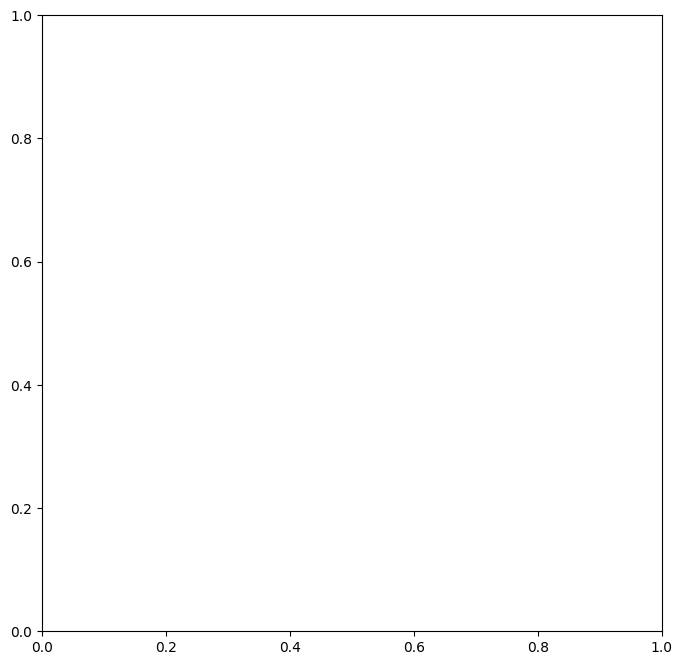

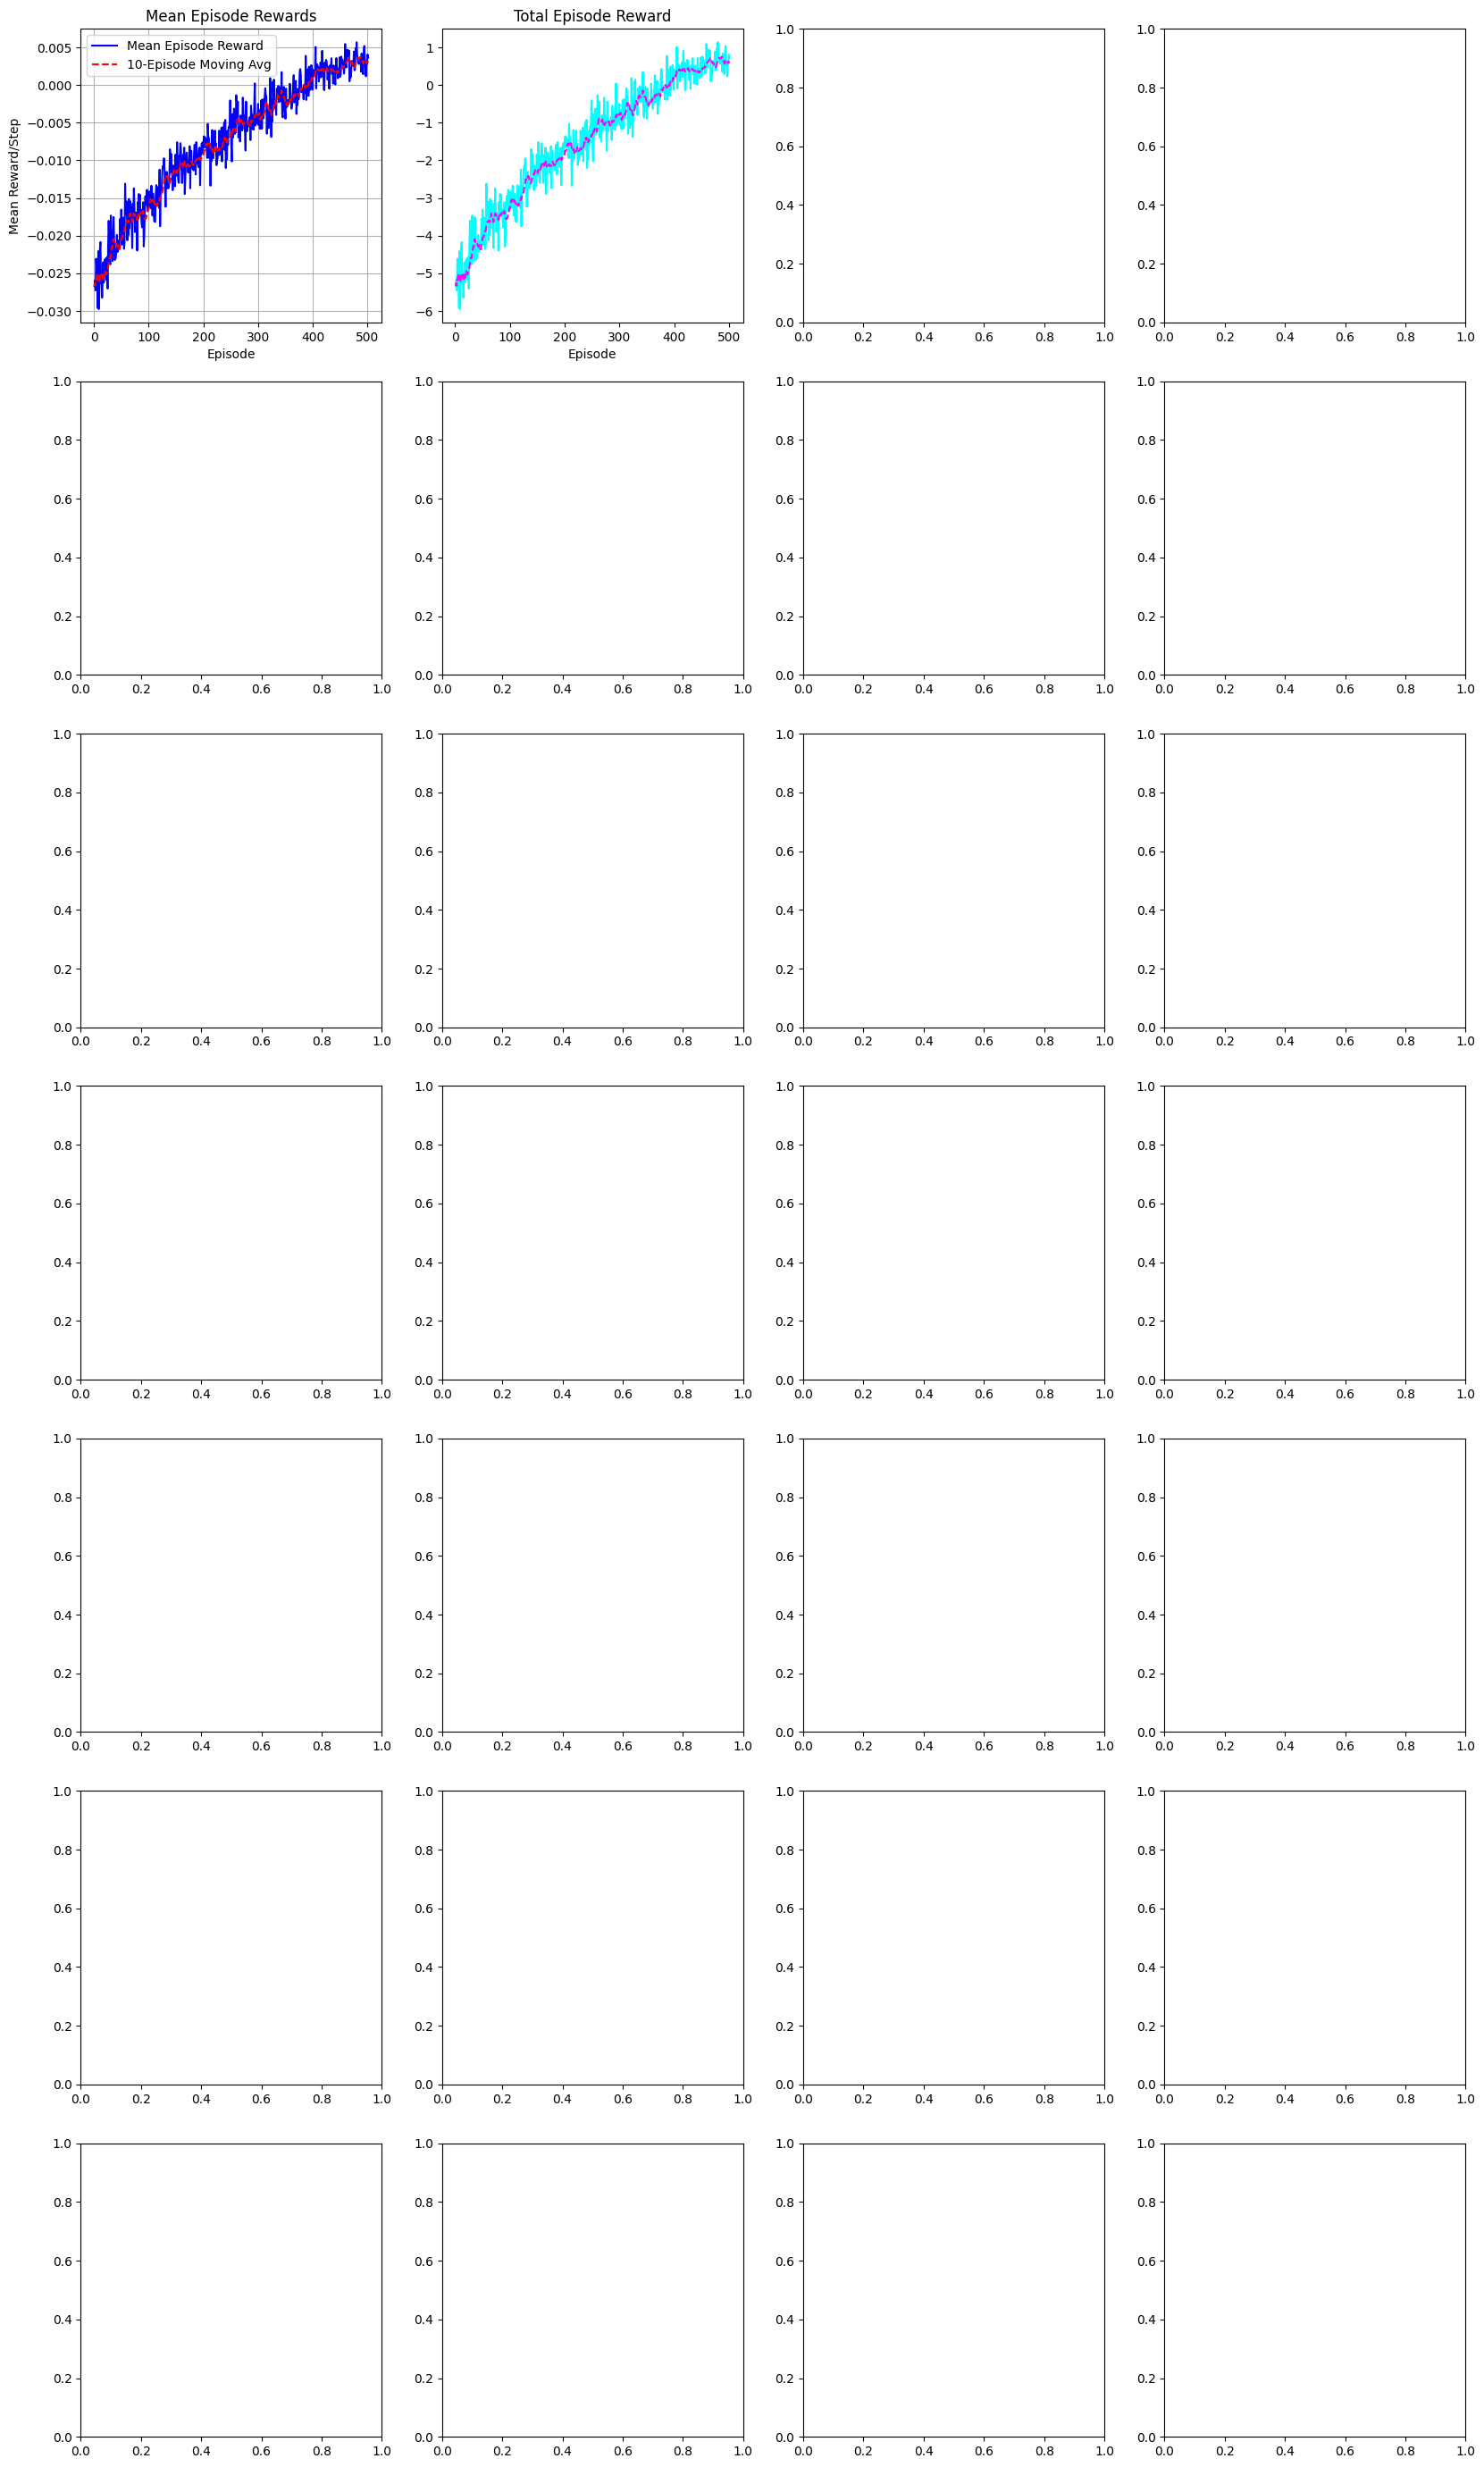

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from IPython.display import clear_output
import random
import gymnasium as gym
from gymnasium.spaces import Box
from shimmy.openai_gym_compatibility import GymV21CompatibilityV0

class TrainingLogger(BaseCallback):
    def __init__(self):
        super(TrainingLogger, self).__init__()
        self.episode_rewards = []
        self.episode_steps = []
        self.temp_metrics = defaultdict(list)
        self.episode_metrics = defaultdict(list)
        self.current_episode_steps = 0
        self.total_timesteps = 0

    def _on_step(self) -> bool:
        info = self.locals['infos'][0]
        reward = self.locals['rewards'][0]
        self.temp_metrics['rewards'].append(reward / 10.0)
        for key in info:
            if isinstance(info[key], dict):
                value = sum(info[key].values())
            else:
                value = info[key]
            self.temp_metrics[key].append(value)
        self.current_episode_steps += 1
        self.total_timesteps += 1

        if self.locals['dones'][0]:
            episode_reward = sum(self.temp_metrics['rewards'])
            self.episode_rewards.append(episode_reward)
            self.episode_steps.append(self.current_episode_steps)
            for key in self.temp_metrics:
                if key != 'rewards':
                    self.episode_metrics[key].append(np.mean(self.temp_metrics[key]))
            print(f"Episode {len(self.episode_rewards)}: Reward={episode_reward:.2f}, Steps={self.current_episode_steps}")

            # Save to ppotrainlogger.txt every 10 episodes
            if len(self.episode_rewards) % 10 == 0:
                mean_episode_reward = episode_reward / self.current_episode_steps if self.current_episode_steps > 0 else 0.0
                with open('ppotrainlogger.txt', 'a') as f:
                    f.write(f"Episode {len(self.episode_rewards)}:\n")
                    f.write(f"  Frame: {self.total_timesteps}\n")
                    f.write(f"  Mean Episode Reward: {mean_episode_reward:.4f}\n")
                    f.write(f"  Total Episode Reward: {episode_reward:.4f}\n")
                    f.write("  Info Metrics:\n")
                    for key in self.episode_metrics:
                        if key != 'rewards' and self.episode_metrics[key]:
                            f.write(f"    {key}: {self.episode_metrics[key][-1]:.4f}\n")
                    f.write("\n")

            self.temp_metrics = defaultdict(list)
            self.current_episode_steps = 0

        return True

    def _plot(self, frame_idx: int, save: bool = False):
        if not self.episode_rewards:
            return
        clear_output(True)
        fig, axes = plt.subplots(7, 4, figsize=(20, 35))
        episodes = range(1, len(self.episode_rewards) + 1)

        # Mean Episode Reward
        mean_episode_rewards = [r / s for r, s in zip(self.episode_rewards, self.episode_steps)]
        axes[0, 0].plot(episodes, mean_episode_rewards, label="Mean Episode Reward", color='blue')
        if len(mean_episode_rewards) >= 10:
            moving_avg = [np.mean(mean_episode_rewards[max(0, i-9):i+1]) for i in range(len(mean_episode_rewards))]
            axes[0, 0].plot(episodes, moving_avg, label="10-Episode Moving Avg", color='red', linestyle='--')
        axes[0, 0].set_title("Mean Episode Rewards")
        axes[0, 0].set_xlabel("Episode")
        axes[0, 0].set_ylabel("Mean Reward/Step")
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Total Episode Reward
        axes[0, 1].plot(episodes, self.episode_rewards, label="Total Episode Reward", color='cyan')
        if len(self.episode_rewards) >= 10:
            moving_avg_total = [np.mean(self.episode_rewards[max(0, i-9):i+1]) for i in range(len(self.episode_rewards))]
            axes[0, 1].plot(episodes, moving_avg_total, label="10-Episode Moving Avg", color='magenta', linestyle='--')
        axes[0, 1].set_title("Total Episode Reward")
        axes[0, 1].set_xlabel("Episode")
        съaxes[0, 1].set_ylabel("Total Reward")
        axes[0, 1].grid(True)
        axes[0, 1].legend()

        # Info Metrics (including 'average_latency' if present)
        info_keys = [k for k in self.episode_metrics.keys() if k != 'rewards']
        for i, key in enumerate(info_keys):
            row = (i + 2) // 4
            col = (i + 2) % 4
            ax = axes[row, col]
            ax.plot(episodes, self.episode_metrics[key], label=key)
            ax.set_title(f"Avg {key}")
            ax.set_xlabel("Episode")
            ax.set_ylabel(key)
            ax.grid(True)
            ax.legend()

        # Hide unused subplots
        for i in range(len(info_keys) + 2, 28):
            row = i // 4
            col = i % 4
            if row < 7:
                axes[row, col].axis('off')

        plt.tight_layout()
        if save:
            plt.savefig("final_training_plot.png")
        plt.show()
        plt.close()

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)

def create_mobile_network_env():
    env = MobileNetwork(
        num_base_stations=36,
        num_users=100,
        num_channels=775,
        area_size=2000,
        bs_loc=[
            (500,560), (1500,560), (500,1420), (1500,1420), (160,160), (160,480), (160,840), (480,160), (480,880),
            (840,160), (840,480), (840,840), (1160,160), (1160,480), (1480,160), (1480,880), (1800,160), (1800,480),
            (1160,840), (1800,840), (160,1120), (160,1440), (480,1120), (840,1120), (840,1440), (160,1800), (480,1800),
            (840,1800), (1160,1120), (1520,1120), (1800,1120), (1160,1440), (1160,1800), (1800,1440), (1520,1800), (1800,1800)
        ]
    )
    if not isinstance(env, gym.Env):
        env = GymV21CompatibilityV0(env=env)
    return env

class FlattenedMobileNetworkEnv(gym.Env):
    def __init__(self):
        super(FlattenedMobileNetworkEnv, self).__init__()
        self.env = create_mobile_network_env()
        self.observation_space = self._get_flattened_observation_space()
        self.action_space = self.env.action_space
        self.base_stations = getattr(self.env, 'base_stations', [])
        self.num_base_stations = 36

    def _get_flattened_observation_space(self):
        obs_shape = self.env.observation_space.shape
        node_feature_dim = obs_shape[1]
        num_nodes = obs_shape[0]
        type_feature_dim = 2
        total_feature_dim = node_feature_dim + type_feature_dim
        flattened_dim = num_nodes * total_feature_dim

        low_nodes = self.env.observation_space.low
        high_nodes = self.env.observation_space.high
        low_type = np.zeros((num_nodes, type_feature_dim), dtype=np.float32)
        high_type = np.ones((num_nodes, type_feature_dim), dtype=np.float32)
        low = np.concatenate([low_nodes, low_type], axis=1).flatten()
        high = np.concatenate([high_nodes, high_type], axis=1).flatten()
        return Box(low=low, high=high, shape=(flattened_dim,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed)
        return self._preprocess_observation(obs), info

    def step(self, action):
        next_state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return self._preprocess_observation(next_state), reward / 10.0, done, truncated, info

    def render(self):
        if hasattr(self.env, 'render'):
            return self.env.render()
        return None

    def close(self):
        if hasattr(self.env, 'close'):
            self.env.close()

    def _preprocess_observation(self, obs):
        if np.any(np.isnan(obs)):
            obs = np.nan_to_num(obs, nan=0.0)
        type_features = np.zeros((self.num_base_stations, 2), dtype=np.float32)
        for i, bs in enumerate(self.base_stations):
            type_features[i] = [1, 0] if getattr(bs, 'type_bs', None) == 'Ma' else [0, 1]
        x = np.concatenate([obs, type_features], axis=1)
        return x.flatten()

def train_model_with_logging(num_frames, plotting_interval=200, seed=42):
    env = DummyVecEnv([lambda: FlattenedMobileNetworkEnv()])
    model = PPO(
        policy="MlpPolicy",
        env=env,
        learning_rate=2e-4,  # Aligned with SAC
        n_steps=2048,        # Steps per update
        batch_size=512,      # Aligned with SAC
        n_epochs=10,         # Number of optimization epochs
        gamma=0.99,          # Discount factor
        gae_lambda=0.95,     # GAE for advantage estimation
        clip_range=0.2,      # Policy clipping range
        seed=seed,
        verbose=1
    )
    logger = TrainingLogger()
    model.learn(total_timesteps=num_frames, callback=logger)
    model.save("ppo_model")
    logger._plot(num_frames, save=True)
    return logger

if __name__ == "__main__":
    seed = 42
    seed_everything(seed)
    logger = train_model_with_logging(num_frames=100000)
    env = DummyVecEnv([lambda: FlattenedMobileNetworkEnv()])
    model = PPO.load("ppo_model")
    scores = []
    for _ in range(5):
        state = env.reset()
        done = False
        score = 0
        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, reward, done, _ = env.step(action)
            score += reward[0]  # VecEnv returns reward as array
        scores.append(score)
    print(f"Average score over 5 episodes: {np.mean(scores):.2f} ± {np.std(scores):.2f}")
    env.close()